# 🚀 Practice Day 09

**📅 Date:** 2026-09-21  
**📁 Category:** Phase 3 · 시각화 스토리텔링 Seaborn (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Move beyond basic matplotlib into Seaborn-specific chart types: boxplot, heatmap (matplotlib 기본기를 넘어 Seaborn 전용 차트: boxplot, heatmap)
- Compare a distribution across groups, not just a single average (평균 하나가 아니라 그룹별 분포 전체를 비교)
- Read a correlation heatmap across several metrics at once (여러 지표 간 상관관계를 heatmap 하나로 한눈에 파악)

---
# 📂 Dataset

**Dataset Name:** Mobile App User Behavior Data (모바일 앱 사용자 행동 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 280 app users with platform (iOS/Android), subscription status (Free/Premium), days since install, and three engagement metrics (session count, average session duration, screens viewed). Premium users are built to run meaningfully more engaged than Free users, and the three engagement metrics are correlated with each other (while days_since_install is not) — a realistic pattern for a heatmap to reveal.
(앱 사용자 280명 — 플랫폼(iOS/Android), 구독 상태(Free/Premium), 설치 후 경과일, 참여 지표 3종(세션 수, 평균 세션 시간, 화면 조회수) 포함. Premium 사용자가 Free보다 확연히 더 활발하게 설계했고, 참여 지표 3종은 서로 상관관계가 있는 반면 설치 후 경과일은 그렇지 않도록 만들어서 heatmap에서 실제로 드러나는 패턴이 있습니다.)

## Dataset Preview

In [27]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_users = 280

platform = np.random.choice(['iOS', 'Android'], size=n_users, p=[0.55, 0.45])
subscription_status = np.random.choice(['Free', 'Premium'], size=n_users, p=[0.72, 0.28])
days_since_install = np.random.randint(1, 366, size=n_users)

# a shared latent "engagement level" drives session_count / duration / screens_viewed together,
# so the three end up correlated with each other - Premium users get a boost
base_engagement = np.random.lognormal(mean=0.0, sigma=0.45, size=n_users)
premium_boost = np.where(subscription_status == 'Premium', 1.6, 1.0)
engagement = base_engagement * premium_boost

session_count = np.clip((engagement * 12 + np.random.normal(0, 3, n_users)).round().astype(int), 1, None)
avg_session_duration_min = np.round(engagement * 4.5 + np.random.normal(0, 1.2, n_users), 1)
avg_session_duration_min = np.clip(avg_session_duration_min, 0.5, None)
screens_viewed = np.clip((engagement * 6 + np.random.normal(0, 2, n_users)).round().astype(int), 1, None)

df = pd.DataFrame({
    'user_id': [f'USER-{i+1:04d}' for i in range(n_users)],
    'platform': platform,
    'subscription_status': subscription_status,
    'days_since_install': days_since_install,
    'session_count': session_count,
    'avg_session_duration_min': avg_session_duration_min,
    'screens_viewed': screens_viewed,
})

df.head()

,user_id,platform,subscription_status,days_since_install,session_count,avg_session_duration_min,screens_viewed
0,USER-0001,iOS,Premium,66,7,3.7,6
1,USER-0002,Android,Free,75,12,3.3,7
2,USER-0003,Android,Free,103,6,2.5,4
3,USER-0004,Android,Free,192,14,4.5,9
4,USER-0005,iOS,Free,252,21,5.7,10


## Dataset Information

In [28]:
# Dataset Information
print(df.shape)
df.info()
df.describe()

(280, 7)
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   280 non-null    str    
 1   platform                  280 non-null    str    
 2   subscription_status       280 non-null    str    
 3   days_since_install        280 non-null    int64  
 4   session_count             280 non-null    int64  
 5   avg_session_duration_min  280 non-null    float64
 6   screens_viewed            280 non-null    int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 15.4 KB


,days_since_install,session_count,avg_session_duration_min,screens_viewed
count,280.000000,280.000000,280.000000,280.000000
mean,178.146429,15.603571,5.723571,7.792857
std,111.713166,8.772921,3.374203,4.776730
min,1.000000,1.000000,0.500000,1.000000
25%,78.000000,10.000000,3.400000,5.000000
50%,178.500000,14.000000,5.100000,7.000000
75%,282.000000,19.000000,7.200000,10.000000
max,365.000000,59.000000,23.100000,32.000000


---
# ❓ Business Questions

1. What is the average session count and average session duration for Free vs Premium users? (Free vs Premium 사용자의 평균 세션 수와 평균 세션 시간은?)
2. How does average screens viewed differ between iOS and Android users? (iOS와 Android 사용자의 평균 화면 조회수 차이는?)
3. What is the correlation coefficient between session_count and screens_viewed? (session_count와 screens_viewed의 상관계수는?)
4. How does the distribution of session_count compare between Free and Premium users (not just the average)? (평균만이 아니라 분포 전체로 봤을 때, Free vs Premium의 session_count는 어떻게 다른가?)
5. How do all four numeric engagement metrics correlate with each other? (4개의 수치형 지표는 서로 어떤 상관관계를 보이는가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `groupby`, `agg`, `Series.corr`, `DataFrame.corr`
  (groupby, agg, 두 컬럼 상관, 상관 행렬)
- [ ] SQL
- [x] Matplotlib
- [x] Other: Seaborn `boxplot`, `heatmap`

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — user_id/platform/subscription_status are text; counts are int; duration is float
  (텍스트, 횟수는 정수, 세션 시간은 실수)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [29]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
user_id                     0
platform                    0
subscription_status         0
days_since_install          0
session_count               0
avg_session_duration_min    0
screens_viewed              0
dtype: int64

Duplicate rows: 0

Dtypes
user_id                         str
platform                        str
subscription_status             str
days_since_install            int64
session_count                 int64
avg_session_duration_min    float64
screens_viewed                int64
dtype: object

Column names
['user_id', 'platform', 'subscription_status', 'days_since_install', 'session_count', 'avg_session_duration_min', 'screens_viewed']

Text columns — unique counts
user_id                280
platform                 2
subscription_status      2
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is the average session count and average session duration for Free vs Premium users? (Free vs Premium 사용자의 평균 세션 수와 평균 세션 시간은?)

**Result:** Free: **13.29** sessions, **4.84** min. Premium: **20.83** sessions, **7.71** min.
(Free는 세션 13.29회, 4.84분. Premium은 세션 20.83회, 7.71분)

**Insight:** Premium is higher on both metrics. These are means only, so the spread inside each group is not shown here.
(Premium이 두 지표 모두 높음. 평균만 본 것이라 그룹 안의 퍼짐은 안 보임)

In [30]:
# Question 1: Group by subscription_status, compare mean session_count and mean avg_session_duration_min
# (subscription_status로 groupby하여 두 지표의 평균 비교)

data = df.groupby('subscription_status').agg({
    'session_count': 'mean',
    'avg_session_duration_min': 'mean'
}).reset_index()

data

,subscription_status,session_count,avg_session_duration_min
0,Free,13.288660,4.841237
1,Premium,20.825581,7.713953


## Question 2

**Question:** How does average screens viewed differ between iOS and Android users? (iOS와 Android 사용자의 평균 화면 조회수 차이는?)

**Result:** Android **7.95** screens, iOS **7.66** screens. The gap is **0.28** screens.
(Android 7.95, iOS 7.66. 차이는 0.28)

**Insight:** The gap is small, so platform does not separate users on screens viewed.
(차이가 작아서 화면 조회수는 플랫폼으로 갈리지 않음)

In [31]:
# Question 2: Group by platform, compare mean screens_viewed
# (platform으로 groupby하여 screens_viewed 평균 비교)

data = df.groupby('platform').agg(
    avg_screens_viewed=('screens_viewed', 'mean')
    ).reset_index()

display(data)
data['avg_screens_viewed'].diff()

,platform,avg_screens_viewed
0,Android,7.945736
1,iOS,7.662252


0         NaN
1   -0.283485
Name: avg_screens_viewed, dtype: float64

## Question 3

**Question:** What is the correlation coefficient between session_count and screens_viewed? (session_count와 screens_viewed의 상관계수는?)

**Result:** Pearson **0.88**, Spearman **0.81**.
(피어슨 0.88, 스피어만 0.81)

**Insight:** Both are close to 1 and positive, so users who open the app more also view more screens. This is a link, not proof that one causes the other.
(둘 다 1에 가깝고 양수. 앱을 자주 여는 사용자가 화면도 많이 봄. 원인이라는 증거는 아님)

In [32]:
# Question 3: Compute the correlation coefficient between session_count and screens_viewed
# (두 컬럼 간 상관계수 계산, 예: .corr())

print(df['session_count'].corr(df['screens_viewed']))
print(df['session_count'].corr(df['screens_viewed'], method='spearman'))

0.881990788491456
0.8125164587765586


---
# 📈 Visualization

**Chart 1:** Distribution of session_count by subscription status (Seaborn boxplot) — 구독 상태별 session_count 분포

**Interpretation:** Premium has the higher median (**19** vs Free **12**) and a longer box (IQR **11** vs **7**). Free has more outlier dots (**8** vs Premium **3**), while the single largest value is Premium (**59** vs Free **40**).
(Premium이 중앙값이 높고 박스가 김. 극단값 점은 Free가 더 많지만, 가장 큰 값은 Premium)

---

**Chart 2:** Correlation heatmap across the 4 numeric engagement metrics (Seaborn heatmap) — 4개 수치형 지표 간 상관관계 히트맵

**Interpretation:** session_count, avg_session_duration_min, and screens_viewed are positively linked (**0.87** to **0.89**). days_since_install is near zero with all three (**-0.02** to **-0.05**).
(세션 수, 세션 시간, 화면 조회수는 서로 양의 상관 0.87-0.89. 설치 후 경과일은 세 지표 모두와 거의 0)

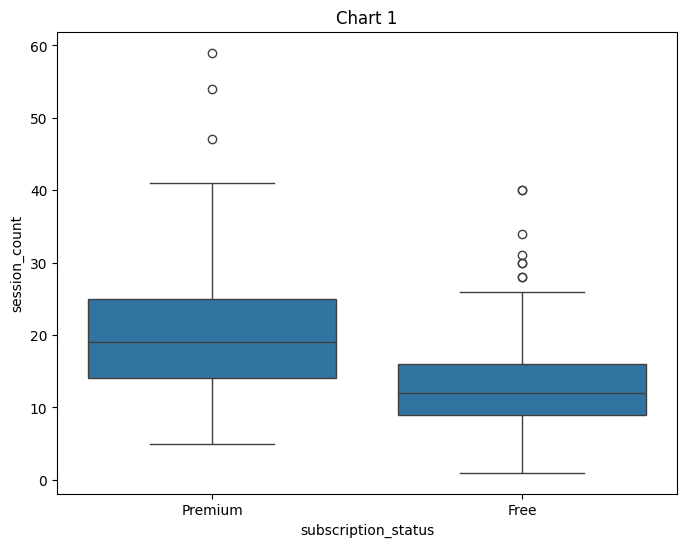

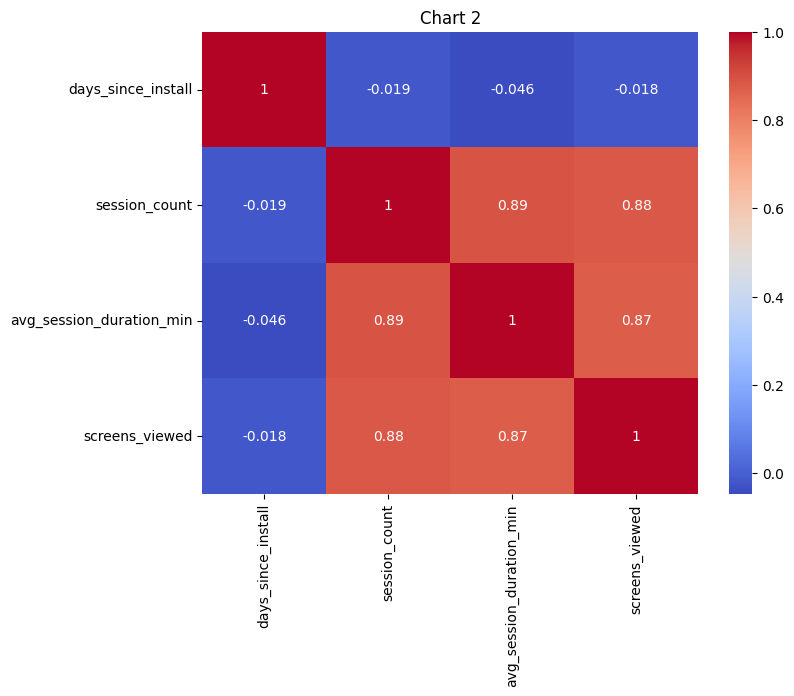

In [33]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Distribution of session_count by subscription_status (Seaborn boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='subscription_status', y='session_count')
plt.title('Chart 1')
plt.show()

# Chart 2: Correlation heatmap across days_since_install / session_count / avg_session_duration_min / screens_viewed
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['days_since_install', 'session_count', 'avg_session_duration_min', 'screens_viewed']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Chart 2')
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Premium is higher on sessions (**20.83** vs **13.29**) and duration (**7.71** vs **4.84** min). The median also favors Premium (**19** vs **12**).
  (Premium이 세션 수와 세션 시간 모두 높음. 중앙값도 Premium이 높음)
- Sessions, duration, and screens move together (**0.87** to **0.89**). days_since_install is near zero with all three (**-0.02** to **-0.05**).
  (세 지표는 함께 움직임. 설치 후 경과일은 거의 무관)
- The iOS vs Android gap in screens is small (**0.28**). Chart 1 shows a longer Premium box (IQR **11** vs **7**) and more Free outlier dots (**8** vs **3**).
  (플랫폼 차이는 작음. Premium 박스가 더 길고, 극단값 점은 Free가 더 많음)
 

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Do not compare Free and Premium by the mean alone. Premium spread is wider (IQR **11** vs **7**), so plan for a range of users, not one average user.
   (평균만으로 Free와 Premium을 비교하지 말 것. Premium은 퍼짐이 커서 평균 사용자 하나로 계획하면 안 됨)
2. Do not split screens-viewed targets by platform. The gap is only **0.28**.
   (화면 조회수 목표를 플랫폼별로 나누지 말 것. 차이는 0.28)
3. Do not count sessions, duration, and screens as three separate signals. They overlap (**0.87** to **0.89**). Do not assume older installs are more engaged (**-0.02**).
   (세 지표를 서로 다른 신호 3개로 세지 말 것. 오래 설치한 사용자가 더 활발하다고 가정하지 말 것)


---
# ❌ Mistakes
**What mistakes did I make today?**

- `df.corr("session_count", "screens_viewed")` fails. The first argument of `df.corr` is `method`, not a column name.
  (`df.corr`의 첫 인자는 컬럼이 아니라 method)
- Q2 first read as "no difference". The gap is small (**0.28**), but means alone do not prove no difference.
  (Q2를 차이 없음으로 읽음. 작다고만 말할 수 있음)
- Outlier dots: Free has more (**8** vs **3**), but the largest single value is Premium (**59**). Count and size are different.
  (극단값은 개수는 Free, 최댓값은 Premium. 개수와 크기는 다름)


---
# ✅ What I Learned
**Today's biggest lesson**

- `df['a'].corr(df['b'])` gives one coefficient; `df[[cols]].corr()` gives the full matrix for the heatmap. `method='spearman'` is a rank-based check.
  (두 컬럼은 Series.corr, 여러 컬럼은 df[[...]].corr(). spearman은 순위 기준 확인)
- A boxplot shows the median, the box (IQR), and outlier dots, not just an average.
  (박스플롯은 평균이 아니라 중앙값, 박스, 극단값 점을 보여줌)
- Mean above median hints at a pull from high values (Free **13.29** vs **12**, Premium **20.83** vs **19**).
  (평균이 중앙값보다 높으면 큰 값의 끌림 신호)


---
# 🧠 Reflection

**What was difficult?**
Calling `corr` correctly, and knowing when Pearson or Spearman fits.
(`corr` 호출 방법, pearson과 spearman 선택)

**Why?**
`df.corr` and `Series.corr` take different arguments, and "straight line" vs "rank" was new.
(두 함수의 인자가 다르고, 직선 관계와 순위 관계 개념이 낯설었음)

**How did I solve it?**
`df['a'].corr(df['b'])` for Q3, then `method='spearman'` as a check. `df[[cols]].corr()` for Chart 2.
(Q3는 Series.corr, 확인은 spearman, 차트 2는 df[[...]].corr())

**What would I do differently next time?**
Read the median and box, not only the mean. Say "small" for a small gap, not "none".
(평균만 보지 말고 중앙값과 박스도 볼 것. 작은 차이는 없다가 아니라 작다고 쓸 것)




---
# ⭐ Self Evaluation

**Understanding**
★★★★★★☆☆☆☆
(상관계수·박스플롯 읽기는 됨. 방식 선택은 도움 필요)

**Confidence**
★★★★★☆☆☆☆☆

**Difficulty**
★★★★★★☆☆☆☆
(`corr` 인자와 spearman 개념이 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 11 — SQL window functions
  (SQL 윈도우 함수)
 